# Projeto de Machine Learning: Predição de Evolução Clínica Grave em casos de COVID-19 (e-SUS Notifica/PB) - Etapa 2

Modelo de classificação para predição de **evolução clínica grave** em casos de COVID-19 a partir de dados do sistema e-SUS Notifica.

---

## Finalidade do Projeto

O objetivo deste projeto é desenvolver um modelo de **Classificação Binária** para estimar o **risco de evolução clínica grave** em pacientes já diagnosticados com COVID-19.

Diferentemente de abordagens anteriores (que se concentravam em identificar se o caso era COVID-19 ou não), este modelo foca na **gravidade do desfecho clínico**. A proposta é auxiliar na identificação de pacientes com maior vulnerabilidade, com base em informações clínicas, demográficas e de imunização disponíveis no momento da notificação ou testagem.

---

## Definição do Problema e Filtros

1. **População de Estudo (Filtro):**  
   Apenas casos com **Classificação Final confirmada para COVID-19** são considerados. Registros descartados ou classificados como outras síndromes gripais são removidos do conjunto de dados.

2. **Variável Alvo (`Y`): Gravidade do Caso (`gravidade`)**  
   A variável alvo é uma representação binária do desfecho clínico, construída a partir da coluna `evolucaoCaso`, conforme os critérios abaixo:

   - **1 (Classe Positiva – Caso Grave):**  
     - Óbito  
     - Internado em UTI  
     - Internado  

   - **0 (Classe Negativa – Caso Não Grave):**  
     - Cura  
     - Tratamento domiciliar  

   Após a criação da variável binária `gravidade`, a coluna original `evolucaoCaso` é removida do dataset.

---

## Transformações e Preparação dos Dados

Durante esta etapa do projeto, foram realizadas as seguintes transformações:

- **Discretização da Idade:**  
  A idade foi convertida para formato numérico e posteriormente discretizada em faixas etárias (Criança, Adolescente, Adulto e Idoso), com remoção da variável original.

- **Tratamento da Vacinação:**  
  O status de vacinação (recebeuVacina) foi binarizado, indicando se o paciente recebeu ao menos uma dose da vacina contra COVID-19 ou não recebeu nenhuma dose, sendo "0" para não recebeu e "1" para recebeu.

- **Tratamento da Evolução de Caso:**  
  A coluna evolucaoCaso também foi binarizada e transformada na coluna Gravidade, conforme explicado no tópico 2 de Variável Alvo.

- **Tratamento de Sintomas e Comorbidades:**  
  As variáveis textuais de sintomas e condições clínicas passaram por limpeza, padronização e codificação por meio de **One-Hot Encoding**, transformando-as em variáveis binárias.

---

## Features (Variáveis Preditoras)

O modelo utilizará as seguintes variáveis para prever o risco de evolução clínica grave:

- **Demográficas:**  
  - Faixa etária  
  - Sexo  

- **Clínicas:**  
  - Sintomas (codificados em variáveis binárias)  
  - Comorbidades / condições clínicas
  - Gravidade (codificados em variáveis binárias)

- **Imunização:**  
  - Status vacinal (recebeuVacina), codificados em binário.

---

## Resultado desta Etapa

Ao final desta etapa, obtém-se um **dataset estruturado, limpo e totalmente numérico**, contendo a variável alvo `gravidade` e todas as variáveis preditoras necessárias, pronto para as etapas seguintes.


## Fonte
- Dados (dataset original): https://opendatasus.saude.gov.br/dataset/notificacoes-de-sindrome-gripal-leve-2024
- Dicionário de Dados: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SGL/pdfs/dicionario-de-dados_e-sus-notifica-opendatasus-1.pdf
- Github (branch da etapa 2): https://github.com/sheilallee/dataset/tree/etapa-2
- Relatório Etapa 2: https://docs.google.com/document/d/1edxfuIFzJeoTswLuE7GTIzq8anqI6b7_MZ9kYXJ9nes/edit?usp=sharing



In [ ]:
!pip install Unidecode

import pandas as pd
import seaborn as srn
import statistics as sts
import numpy as np
import re
from unidecode import unidecode

# CONFIGURAÇÃO DE EXIBIÇÃO DO PANDAS
pd.set_option('display.max_columns', None)

# --- CARREGAMENTO DOS ARQUIVOS ---

# Caminho
url = 'https://raw.githubusercontent.com/sheilallee/dataset/refs/heads/guilherme/dataset_tratado_etapa1.csv'
dataset = pd.read_csv(url, delimiter=';', encoding='utf-8')


dataset.head(10)

,sintomas,condicoes,sexo,idade,evolucaoCaso,codigoRecebeuVacina,codigoDosesVacina
0,"coriza, febre, tosse",sem comorbidades,feminino,30.0,cura,1.0,1
1,"dor de cabeca, tosse, febre, coriza",sem comorbidades,feminino,35.0,cura,1.0,3
2,"coriza, dor de garganta, dor de cabeca",doencas respiratorias cronicas descompensadas,feminino,50.0,cura,1.0,4
3,"dor de cabeca, febre, coriza",sem comorbidades,masculino,37.0,cura,1.0,2
4,"coriza, tosse, febre",sem comorbidades,feminino,35.0,cura,1.0,2
5,"dor de cabeca, tosse, dor de garganta, coriza",sem comorbidades,masculino,40.0,cura,1.0,1
6,dor de garganta,sem comorbidades,feminino,49.0,cura,1.0,2
7,"coriza, tosse",sem comorbidades,masculino,17.0,cura,1.0,3
8,"coriza, dor de cabeca, febre",sem comorbidades,masculino,27.0,cura,1.0,2
9,"dor de cabeca, dor de garganta",sem comorbidades,feminino,28.0,cura,1.0,1


# Discretização

Idade - Ordinal Encoding

In [ ]:
import pandas as pd

# GARANTIR QUE A COLUNA IDADE É NUMÉRICA
dataset['idade'] = pd.to_numeric(dataset['idade'], errors='coerce')

# DISCRETIZAÇÃO MANUAL DA IDADE
# 0 = Criança
# 1 = Adolescente
# 2 = Adulto
# 3 = Idoso

def discretizar_idade_cod(idade):
    if pd.isna(idade):
        return -1 # Retorna -1 se houver erro
    elif idade <= 12:
        return 0  # Criança
    elif idade <= 17:
        return 1  # Adolescente
    elif idade <= 59:
        return 2  # Adulto
    else:
        return 3  # Idoso (>= 60)

# Aplica a função
dataset['faixa_etaria'] = dataset['idade'].apply(discretizar_idade_cod)

# Garante que a coluna seja do tipo INTEIRO (int), não float
dataset['faixa_etaria'] = dataset['faixa_etaria'].astype(int)

# DISTRIBUIÇÃO DA FAIXA ETÁRIA
print('Distribuição da faixa etária (0=Cri, 1=Ado, 2=Adu, 3=Ido):')
print(dataset['faixa_etaria'].value_counts(dropna=False).sort_index())

# REMOVER A COLUNA IDADE ORIGINAL
if 'idade' in dataset.columns:
    dataset.drop(columns=['idade'], inplace=True)

print('Total do dataset:', dataset.shape)

display(dataset.head(50))

Distribuição da faixa etária (0=Cri, 1=Ado, 2=Adu, 3=Ido):
faixa_etaria
0     1065
1      782
2    32180
Name: count, dtype: int64
Total do dataset: (34027, 7)


,sintomas,condicoes,sexo,evolucaoCaso,codigoRecebeuVacina,codigoDosesVacina,faixa_etaria
0,"coriza, febre, tosse",sem comorbidades,feminino,cura,1.0,1,2
1,"dor de cabeca, tosse, febre, coriza",sem comorbidades,feminino,cura,1.0,3,2
2,"coriza, dor de garganta, dor de cabeca",doencas respiratorias cronicas descompensadas,feminino,cura,1.0,4,2
3,"dor de cabeca, febre, coriza",sem comorbidades,masculino,cura,1.0,2,2
4,"coriza, tosse, febre",sem comorbidades,feminino,cura,1.0,2,2
5,"dor de cabeca, tosse, dor de garganta, coriza",sem comorbidades,masculino,cura,1.0,1,2
6,dor de garganta,sem comorbidades,feminino,cura,1.0,2,2
7,"coriza, tosse",sem comorbidades,masculino,cura,1.0,3,1
8,"coriza, dor de cabeca, febre",sem comorbidades,masculino,cura,1.0,2,2
9,"dor de cabeca, dor de garganta",sem comorbidades,feminino,cura,1.0,1,2


# Conversão de atributos categóricos

Binarização para a coluna evolucaoCaso, que se tornará a coluna gravidade, sendo:

gravidade = 1 se evolucaoCaso ∈ {óbito, UTI, internado}
gravidade = 0 se cura ou tratamento domiciliar

In [ ]:
# ==============================================================================
# CRIAÇÃO DA VARIÁVEL BINÁRIA "GRAVIDADE"
# ==============================================================================


# Definição das categorias
casos_graves = [
    'obito',
    'internado em uti',
    'internado'
]

casos_nao_graves = [
    'cura',
    'em tratamento domiciliar',
]

# Função para gerar a variável binária
def classificar_gravidade(valor):
    if valor in casos_graves:
        return 1
    elif valor in casos_nao_graves:
        return 0
    else:
        return None  # Para casos inesperados ou nulos

# Aplicação da função
dataset['gravidade'] = dataset['evolucaoCaso'].apply(classificar_gravidade)

# Remoção da coluna original conforme solicitado
dataset.drop(columns=['evolucaoCaso'], inplace=True)

# ==============================================================================
# VERIFICAÇÃO FINAL
# ==============================================================================

print("Distribuição da variável gravidade:")
print(dataset['gravidade'].value_counts(dropna=False))

print("\nColunas finais do dataset:")
print(dataset.columns.tolist())

display(dataset.head(100))


Distribuição da variável gravidade:
gravidade
0    33590
1      437
Name: count, dtype: int64

Colunas finais do dataset:
['sintomas', 'condicoes', 'sexo', 'codigoRecebeuVacina', 'codigoDosesVacina', 'faixa_etaria', 'gravidade']


,sintomas,condicoes,sexo,codigoRecebeuVacina,codigoDosesVacina,faixa_etaria,gravidade
0,"coriza, febre, tosse",sem comorbidades,feminino,1.0,1,2,0
1,"dor de cabeca, tosse, febre, coriza",sem comorbidades,feminino,1.0,3,2,0
2,"coriza, dor de garganta, dor de cabeca",doencas respiratorias cronicas descompensadas,feminino,1.0,4,2,0
3,"dor de cabeca, febre, coriza",sem comorbidades,masculino,1.0,2,2,0
4,"coriza, tosse, febre",sem comorbidades,feminino,1.0,2,2,0
...,...,...,...,...,...,...,...
95,assintomatico,sem comorbidades,feminino,1.0,2,2,0
96,"coriza, tosse, dor de garganta, dor de cabeca",sem comorbidades,feminino,1.0,2,2,0
97,"dor de cabeca, tosse, dor de garganta, febre",sem comorbidades,feminino,1.0,1,2,0
98,"coriza, dor de cabeca, tosse, dor de garganta",sem comorbidades,feminino,1.0,3,2,0


Binarização para a coluna CodigoRecebeuVacina, sendo:

0 -> Não (não recebeu), 1 -> Sim (recebeu)

In [ ]:
# ==============================================================================
# TRATAMENTO DA VACINAÇÃO (BINARIZAÇÃO)
# Transformar 1 (Sim) e 2 (Não) em 1 e 0 na coluna 'recebeuVacina'
# ==============================================================================

# 1. Função simples para converter
def converter_status_vacina(valor):
    valor_limpo = str(valor).replace('.0', '').strip()

    # Se for '1', retorna 1 (Verdadeiro). Qualquer outra coisa (2, ignorado, etc) vira 0.
    if valor_limpo == '1':
        return 1
    return 0

dataset['recebeuVacina'] = dataset['codigoRecebeuVacina'].apply(converter_status_vacina)

# 3. Remover a coluna antiga
dataset.drop(columns=['codigoRecebeuVacina'], inplace=True)

# ==============================================================================
# VERIFICAÇÃO FINAL
# ==============================================================================
print("Distribuição da nova coluna 'recebeuVacina':")
print(dataset['recebeuVacina'].value_counts(normalize=True))
print("\n(Legenda: 1 = Sim, 0 = Não)")

display(dataset.head(100))

Distribuição da nova coluna 'recebeuVacina':
recebeuVacina
1    0.911952
0    0.088048
Name: proportion, dtype: float64

(Legenda: 1 = Sim, 0 = Não)


,sintomas,condicoes,sexo,codigoDosesVacina,faixa_etaria,gravidade,recebeuVacina
0,"coriza, febre, tosse",sem comorbidades,feminino,1,2,0,1
1,"dor de cabeca, tosse, febre, coriza",sem comorbidades,feminino,3,2,0,1
2,"coriza, dor de garganta, dor de cabeca",doencas respiratorias cronicas descompensadas,feminino,4,2,0,1
3,"dor de cabeca, febre, coriza",sem comorbidades,masculino,2,2,0,1
4,"coriza, tosse, febre",sem comorbidades,feminino,2,2,0,1
...,...,...,...,...,...,...,...
95,assintomatico,sem comorbidades,feminino,2,2,0,1
96,"coriza, tosse, dor de garganta, dor de cabeca",sem comorbidades,feminino,2,2,0,1
97,"dor de cabeca, tosse, dor de garganta, febre",sem comorbidades,feminino,1,2,0,1
98,"coriza, dor de cabeca, tosse, dor de garganta",sem comorbidades,feminino,3,2,0,1


In [ ]:
# ==============================================================================
# TRATAMENTO DO SEXO (TRANSFORMAÇÃO BINÁRIA)
# ==============================================================================

# Visualizar valores antes da mudança para garantir
print("Valores encontrados em 'sexo' antes do tratamento:", dataset['sexo'].unique())

# Mapeamento Manual (0 e 1)
# Definiremos: 1 = Masculino, 0 = Feminino
mapa_sexo = {
    'masculino': 1,
    'feminino': 0
}

# Aplicando a transformação
dataset['sexo'] = dataset['sexo'].map(mapa_sexo)

# Converter para número Inteiro (int)
dataset['sexo'] = dataset['sexo'].astype(int)

# ==============================================================================
# VERIFICAÇÃO FINAL
# ==============================================================================
print("\nDistribuição final da coluna 'sexo':")
print(dataset['sexo'].value_counts(dropna=False))
print("(Legenda: 1 = Masculino, 0 = Feminino)")

display(dataset.head())

Valores encontrados em 'sexo' antes do tratamento: ['feminino' 'masculino']

Distribuição final da coluna 'sexo':
sexo
0    21489
1    12538
Name: count, dtype: int64
(Legenda: 1 = Masculino, 0 = Feminino)


,sintomas,condicoes,sexo,codigoDosesVacina,faixa_etaria,gravidade,recebeuVacina
0,"coriza, febre, tosse",sem comorbidades,0,1,2,0,1
1,"dor de cabeca, tosse, febre, coriza",sem comorbidades,0,3,2,0,1
2,"coriza, dor de garganta, dor de cabeca",doencas respiratorias cronicas descompensadas,0,4,2,0,1
3,"dor de cabeca, febre, coriza",sem comorbidades,1,2,2,0,1
4,"coriza, tosse, febre",sem comorbidades,0,2,2,0,1


Uso do one-Hot Encoding para as colunas de sintomas e condições:

In [ ]:
# ==============================================================================
# ONE-HOT ENCODING
# ==============================================================================

# 1. TRATAMENTO ESPECÍFICO PARA A VÍRGULA DENTRO DOS PARÊNTESES

texto_problematico = "doencas renais cronicas em estagio avancado (graus 3, 4 ou 5)"
texto_corrigido = "doencas_renais_cronicas"

dataset['condicoes'] = dataset['condicoes'].str.replace(texto_problematico, texto_corrigido, regex=False)

# 2. DEFINIÇÃO DOS MAPAS
mapa_sintomas = {
    'assintomatico': 'sintoma_assintomatico',
    'dor de cabeca': 'sintoma_dor_cabeca',
    'febre': 'sintoma_febre',
    'disturbios gustativos': 'sintoma_gustativo',
    'dor de garganta': 'sintoma_dor_garganta',
    'disturbios olfativos': 'sintoma_olfativo',
    'dispneia': 'sintoma_dispneia',
    'tosse': 'sintoma_tosse',
    'coriza': 'sintoma_coriza',
    'outros': 'sintoma_outros'
}

mapa_condicoes = {
    'sem comorbidades': 'condicao_nenhuma',
    'doencas_renais_cronicas': 'condicao_renal', # Agora usamos o texto corrigido
    'doencas renais cronicas em estagio avancado (graus 3': 'condicao_renal', # Prevenção caso tenha sobrado lixo
    'condicao_renal': 'condicao_renal', # Caso já tenha sido substituido
    'doencas respiratorias cronicas descompensadas': 'condicao_respiratoria',
    'portador de doencas cromossomicas ou estado de fragilidade imunologica': 'condicao_imune_fragil',
    'doencas cardiacas cronicas': 'condicao_cardiaca',
    'diabetes': 'condicao_diabetes',
    'imunossupressao': 'condicao_imunossupressao',
    'gestante': 'condicao_gestante',
    'puerpera (ate 45 dias do parto)': 'condicao_puerpera',
    'obesidade': 'condicao_obesidade',
    'outros': 'condicao_outros'
}

# 3. REMOVER COLUNAS DUPLICADAS OU ERRADAS DO PASSADO

cols_para_apagar = [
    '4 ou 5)', 'doencas renais cronicas em estagio avancado (graus 3', # Lixo do split errado
]



# Removemos duplicatas da lista e aplicamos o drop
cols_para_apagar = list(set(cols_para_apagar))
print(f"Removendo {len(cols_para_apagar)} colunas antigas/sujas...")
dataset = dataset.drop(columns=[c for c in cols_para_apagar if c in dataset.columns], errors='ignore')


# 4. GERAÇÃO E RENOMEAÇÃO
dummies_sintomas = dataset['sintomas'].str.get_dummies(sep=',')
dummies_sintomas.columns = dummies_sintomas.columns.str.strip()
dummies_sintomas.rename(columns=mapa_sintomas, inplace=True)

dummies_condicoes = dataset['condicoes'].str.get_dummies(sep=',')
dummies_condicoes.columns = dummies_condicoes.columns.str.strip()
dummies_condicoes.rename(columns=mapa_condicoes, inplace=True)

# 5. JUNÇÃO FINAL E REMOÇÃO DAS ORIGINAIS
dataset = pd.concat([dataset, dummies_sintomas, dummies_condicoes], axis=1)

# Remover as colunas de texto originais conforme solicitado
dataset.drop(columns=['sintomas', 'condicoes'], inplace=True)

# ==============================================================================
# VERIFICAÇÃO FINAL
# ==============================================================================
# Remove duplicatas de colunas (caso o concat tenha gerado algo estranho, prevenimos aqui)
dataset = dataset.loc[:, ~dataset.columns.duplicated()]


print(f"Total de colunas: {len(dataset.columns)}")
print("Colunas Finais:")
print(dataset.columns.tolist())


display(dataset.head(10))

Removendo 2 colunas antigas/sujas...
Total de colunas: 26
Colunas Finais:
['sexo', 'codigoDosesVacina', 'faixa_etaria', 'gravidade', 'recebeuVacina', 'sintoma_coriza', 'sintoma_dispneia', 'sintoma_gustativo', 'sintoma_olfativo', 'sintoma_dor_cabeca', 'sintoma_dor_garganta', 'sintoma_febre', 'sintoma_outros', 'sintoma_tosse', 'sintoma_assintomatico', 'condicao_diabetes', 'condicao_cardiaca', 'condicao_respiratoria', 'condicao_renal', 'condicao_gestante', 'condicao_imunossupressao', 'condicao_obesidade', 'condicao_outros', 'condicao_imune_fragil', 'condicao_puerpera', 'condicao_nenhuma']


,sexo,codigoDosesVacina,faixa_etaria,gravidade,recebeuVacina,sintoma_coriza,sintoma_dispneia,sintoma_gustativo,sintoma_olfativo,sintoma_dor_cabeca,sintoma_dor_garganta,sintoma_febre,sintoma_outros,sintoma_tosse,sintoma_assintomatico,condicao_diabetes,condicao_cardiaca,condicao_respiratoria,condicao_renal,condicao_gestante,condicao_imunossupressao,condicao_obesidade,condicao_outros,condicao_imune_fragil,condicao_puerpera,condicao_nenhuma
0,0,1,2,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
1,0,3,2,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,0,4,2,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,2,2,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,2,2,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
5,1,1,2,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
6,0,2,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,1,3,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
8,1,2,2,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
9,0,1,2,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


#Planejamento Experimental

Nesta etapa, definimos a estratégia para treinamento, validação e otimização do modelo preditivo de risco de óbito.

### Particionamento dos Dados
Dada a natureza do problema (classificação de risco de óbito), observamos um **desbalanceamento de classes**, onde o número de casos de cura é significativamente maior que o de óbitos.

* **Estratégia:** Divisão em Treino (80%) e Teste (20%).
* **Justificativa:** Utilizamos a **Amostragem Estratificada (`stratify=y`)**. Isso é fundamental para garantir que a proporção de óbitos seja mantida tanto no conjunto de treino quanto no de teste. Uma divisão aleatória simples poderia deixar o conjunto de teste com poucos (ou nenhum) exemplos de óbito, invalidando a avaliação.

### Técnica de Validação
Utilizaremos a **Validação Cruzada Estratificada (Stratified K-Fold Cross-Validation)** com $k=5$ ou $k=10$.
* **Justificativa:** O *Holdout* simples (apenas treino/teste) pode ser enganoso dependendo de quais linhas caem no teste. A validação cruzada treina e testa o modelo em diferentes subconjuntos dos dados, fornecendo uma estimativa mais robusta e realista da performance (média e desvio padrão das métricas).

### Escolha do Algoritmo
O algoritmo principal escolhido para este experimento é o **Random Forest (Floresta Aleatória)**.

**Justificativas:**
1.  **Robustez a Overfitting:** Por ser um método *ensemble* (conjunto de árvores de decisão), ele generaliza melhor que uma única árvore de decisão.
2.  **Lidar com Desbalanceamento:** O algoritmo permite o uso de pesos nas classes (`class_weight='balanced'`), penalizando mais o erro na classe minoritária (óbito), o que é crucial para nosso problema.
3.  **Interpretabilidade:** Permite extrair a "Importância das Features", ajudando a entender quais fatores (idade, vacina, comorbidades) mais impactam no risco de óbito, o que é valioso para a área de saúde.

### Otimização de Hiperparâmetros
Para encontrar a melhor configuração do modelo, não utilizaremos os valores padrão (default). Aplicaremos o método **RandomizedSearchCV**.

* **Estratégia:** Definimos uma grade de parâmetros (número de árvores, profundidade máxima, etc.) e o algoritmo testará combinações aleatórias usando validação cruzada.
* **Justificativa:** O *Randomized Search* é computacionalmente mais eficiente que o *Grid Search* (que testa todas as combinações possíveis) e tende a encontrar resultados muito próximos do ótimo em menos tempo.
* **Métrica de Otimização:** Otimizaremos buscando maximizar o **Recall (Sensibilidade)** ou **ROC-AUC**, pois em saúde é mais grave não detectar um paciente de risco (Falso Negativo) do que classificar um paciente saudável como risco (Falso Positivo).

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Definindo X (Features) e y (Target)
# A variável alvo agora é 'gravidade'
y = dataset['gravidade']

# Removemos a target e colunas que não devem entrar na predição
# (Incluindo 'evolucaoCaso' antigo se ele ainda existir, para evitar vazamento de dados)
cols_remover = ['gravidade', 'evolucaoCaso']
X = dataset.drop(columns=[c for c in cols_remover if c in dataset.columns])

# 2. Divisão Treino e Teste (Estratificada)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Verificação
print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste: {X_test.shape}")
print("-" * 30)
print("Proporção da classe 'Gravidade' (1) no Treino:")
print(y_train.value_counts(normalize=True))
print("Proporção da classe 'Gravidade' (1) no Teste:")
print(y_test.value_counts(normalize=True))

Dimensões do Treino: (27221, 25)
Dimensões do Teste: (6806, 25)
------------------------------
Proporção da classe 'Gravidade' (1) no Treino:
gravidade
0    0.987142
1    0.012858
Name: proportion, dtype: float64
Proporção da classe 'Gravidade' (1) no Teste:
gravidade
0    0.987217
1    0.012783
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# 1. Instanciando o modelo base
# class_weight='balanced' ajusta o peso para dar atenção à classe minoritária (Graves/Óbitos)
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Definindo a grade de parâmetros para testar
param_grid = {
    'n_estimators': [100, 200, 300],       # Qtd de árvores
    'max_depth': [None, 10, 20, 30],       # Profundidade máxima
    'min_samples_split': [2, 5, 10],       # Mínimo para dividir nó
    'min_samples_leaf': [1, 2, 4],         # Mínimo na folha
    'max_features': ['sqrt', 'log2']       # Features por árvore
}

# 3. Configurando a busca aleatória (Otimização)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,             # Tenta 10 combinações diferentes
    cv=5,                  # Validação cruzada de 5 partes
    verbose=1,             # Mostra mensagens de progresso
    random_state=42,
    n_jobs=-1,             # Usa processamento paralelo
    scoring='roc_auc'      # Foca na qualidade da separação das classes
)

# 4. Treinando (Isso pode levar alguns minutos)
print("Iniciando treinamento e otimização...")
random_search.fit(X_train, y_train)

print("\nMelhores hiperparâmetros encontrados:")
print(random_search.best_params_)

Iniciando treinamento e otimização...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhores hiperparâmetros encontrados:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      6719
           1       0.19      0.87      0.31        87

    accuracy                           0.95      6806
   macro avg       0.59      0.91      0.64      6806
weighted avg       0.99      0.95      0.97      6806

ROC-AUC Score: 0.9368


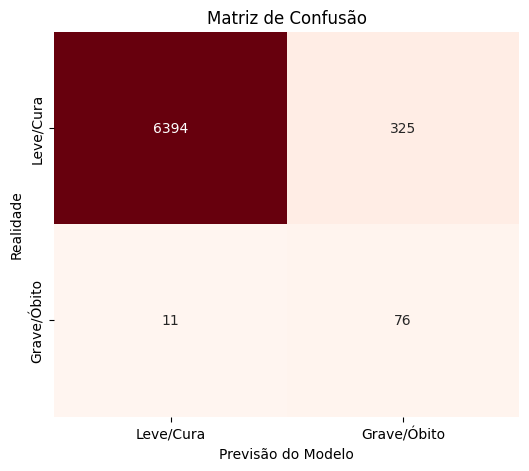

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Previsões com o melhor modelo
melhor_modelo = random_search.best_estimator_
y_pred = melhor_modelo.predict(X_test)
y_proba = melhor_modelo.predict_proba(X_test)[:, 1]

# 2. Métricas Numéricas
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_score:.4f}")

# 3. Matriz de Confusão
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Matriz de Confusão')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.xticks([0.5, 1.5], ['Leve/Cura', 'Grave/Óbito'])
plt.yticks([0.5, 1.5], ['Leve/Cura', 'Grave/Óbito'])
plt.show()